In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap


In [2]:
transcriptomics_data = "../data/0_data_for_mlp/TCGA-BRCA.star_tpm.csv"
clinical_data = "../data/clinical_data/brca_clinical/all_samples.csv"

In [3]:
expr = pd.read_csv(transcriptomics_data, index_col=0)
meta = pd.read_csv(clinical_data)

In [4]:
meta = meta.set_index("case_id")
common = expr.index.intersection(meta.index)

In [5]:
expr = expr.loc[common]
meta = meta.loc[common]


In [6]:
# === 3. Standaryzacja ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(expr)

In [7]:
# === 4. PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

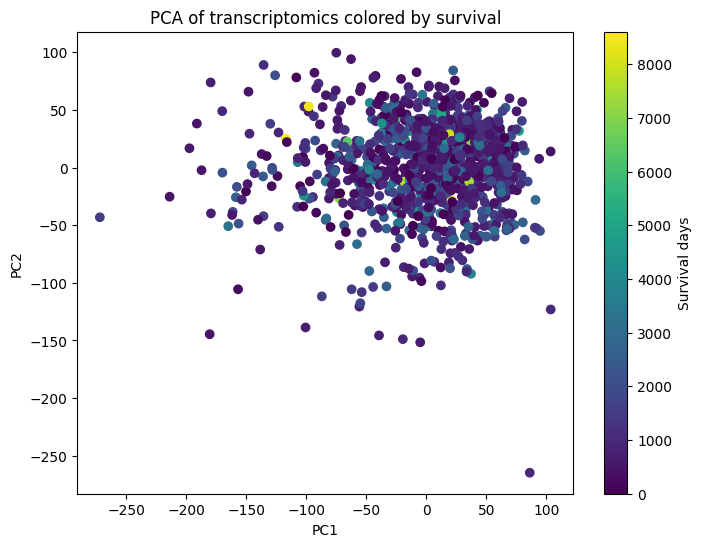

In [8]:
# === 5. Plot ===
plt.figure(figsize=(8,6))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=meta["dss_survival_days"],
    cmap="viridis"
)

plt.colorbar(sc, label="Survival days")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of transcriptomics colored by survival")

plt.show()

/scratch/2370352/conda/envs/myenv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


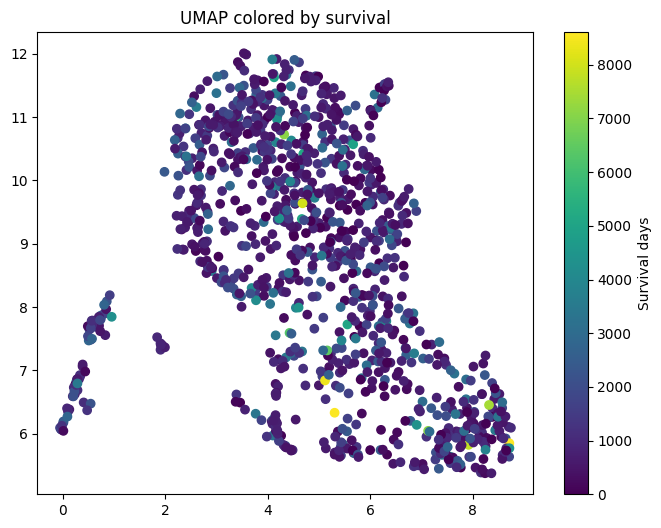

In [10]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=meta["dss_survival_days"],
    cmap="viridis"
)

plt.colorbar(sc, label="Survival days")
plt.title("UMAP colored by survival")

plt.show()

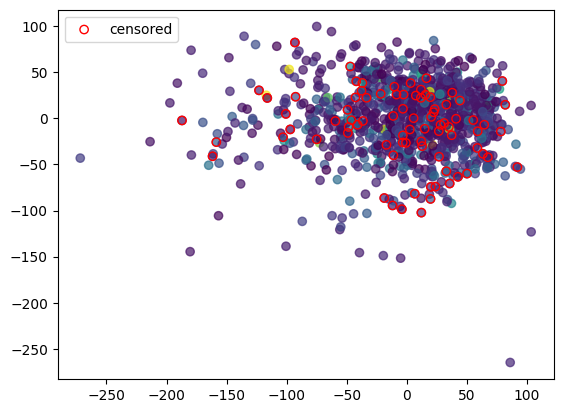

In [11]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=meta["dss_survival_days"],
    cmap="viridis",
    alpha=0.7
)

# zaznacz censored jako inne markery
censored = meta["dss_censorship"] == 0

plt.scatter(
    X_pca[censored,0],
    X_pca[censored,1],
    facecolors='none',
    edgecolors='red',
    label="censored"
)

plt.legend()

<Axes: >

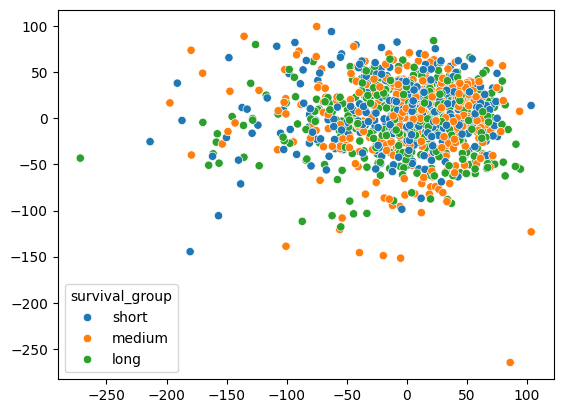

In [13]:
meta["survival_group"] = pd.qcut(
    meta["dss_survival_days"],
    q=3,
    labels=["short", "medium", "long"]
)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=meta["survival_group"]
)

In [24]:
corrs = []

for gene in expr.columns:
    x = expr[gene]
    y = meta["dss_survival_days"]

    if x.std() == 0:
        corrs.append(0)
        continue

    corr = np.corrcoef(x, y)[0,1]

    if np.isnan(corr):
        corr = 0

    corrs.append(corr)

corrs = np.array(corrs)

# top geny
top_idx = np.argsort(np.abs(corrs))[-100:]
top_genes = expr.columns[top_idx]
expr_small = expr[top_genes]


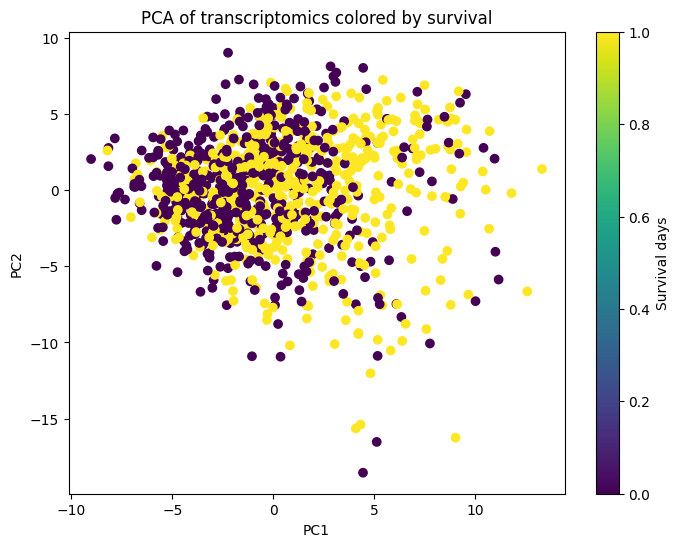

In [31]:
# === 3. Standaryzacja ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(expr_small)

# === 4. PCA ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# === 5. Plot ===
plt.figure(figsize=(8,6))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=meta["group"],
    cmap="viridis"
)

plt.colorbar(sc, label="Survival days")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of transcriptomics colored by survival")

plt.show()

/scratch/2370352/conda/envs/myenv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


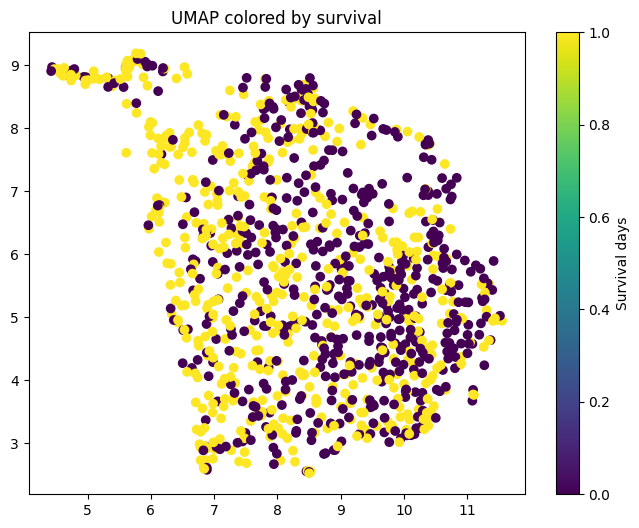

In [30]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=meta["group"],
    cmap="viridis"
)

plt.colorbar(sc, label="Survival days")
plt.title("UMAP colored by survival")

plt.show()

In [28]:
meta["group"] = (meta["dss_survival_days"] > meta["dss_survival_days"].median()).astype(int)